## Engranes y poleas


In [1]:
import numpy as np
import matplotlib.pyplot as plt
P_motriz=10 #[HP]
rpm_motor= 120 #[rpm]
N_f=1.6
print(f'la potencia motriz es de {P_motriz*746}')
d_b=0.06 #[m]
d_c=0.12 #[m]
d_d=0.15 #[m]
d_e=0.05 #[m]
d_f=0.18 #[m]
d_g=0.08 #[m]
d_eje=0.04#[m]

theta=20*np.pi/180
theta_DE=np.asin((d_d/2-d_e/2)/0.5) #distancia de D a E es de 500 mm
theta_FG=np.asin((d_f/2-d_g/2)/0.6) #distancia de F a G es de 600 mm
beta_DE=np.pi-2*theta_DE
beta_FG=np.pi-2*theta_FG
print(f'theta DE={theta_DE} rad ó {theta_DE*180/np.pi}°')
print(f'theta FG={theta_FG} rad ó {theta_FG*180/np.pi}°')
u_s=0.3

la potencia motriz es de 7460
theta DE=0.10016742116155979 rad ó 5.739170477266786°
theta FG=0.083430086610615 rad ó 4.780191847199159°


- M : Momento
- F : Fuerza
- R : Reacción de fuerza
- T : Tensión
- _X: en X
- _X(x ó Y): eje de coordenada x o y
- _X(1 ó 2): 1>2

![WhatsApp Image 2026-10-03 at 5.10.20 PM.jpeg](<attachment:WhatsApp Image 2026-10-03 at 5.10.20 PM.jpeg>)
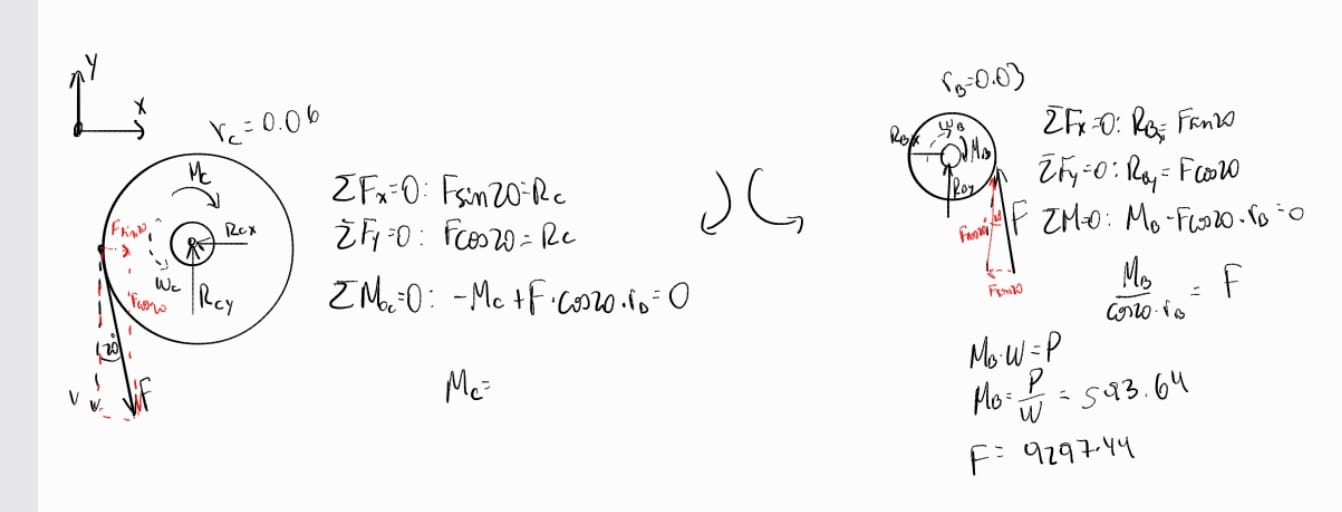

In [2]:
#DCL POLEA B
M_B=P_motriz *746/(rpm_motor*np.pi /30) #[N·m]
F=M_B/(np.cos(theta)*d_b/2)
R_BX=F*np.sin(theta) #[N]
R_BY=F*np.cos(theta) #[N]
print('Fuerzas en polea B')
print(f'M_B:{M_B} N·m, R_B:{R_BX} N, R_B: {R_BY}N')
print('-'*80)
#DCL POLEA C
R_CX=F*np.sin(theta) #[N]
R_CY=F*np.cos(theta) #[N]
M_C=F*np.cos(theta)*d_c/2 #[N·m]
print('Fuerzas en polea C')
print(f'M_C:{M_C} N·m, R_C:{R_CX} N, R_C: {R_CY} N')

Fuerzas en polea B
M_B:593.6479377327697 N·m, R_B:7202.33929894147 N, R_B: 19788.264591092324N
--------------------------------------------------------------------------------
Fuerzas en polea C
M_C:1187.2958754655394 N·m, R_C:7202.33929894147 N, R_C: 19788.264591092324 N


In [3]:
#POTENCIA EN EJE
omega_B= -rpm_motor*2*np.pi/60 #[rad /s] signo quiere decir z negativo
omega_C=-omega_B*d_b/d_c #[rad/s]
omega_eje=omega_C
P_eje=omega_eje*M_C
#Consideración de momentos que se llevan las poleas
P_D=0.5*P_eje #Si potencia en polea D es del 50%
P_F=P_eje-P_D
M_D=P_D/omega_eje #Por si P_D no es 0.5, los momentos de torsion cambiaran
M_F=P_F/omega_eje #lo mismo aca
print(P_D,P_F, M_D,M_F)
print(f'{P_eje} W') #Confirmado que da la misma potencia en W que la potencia que se entrega en el motor

3730.0 3730.0 593.6479377327697 593.6479377327697
7460.0 W


![WhatsApp Image 2026-10-03 at 5.11.40 PM.jpeg](<attachment:WhatsApp Image 2026-10-03 at 5.11.40 PM.jpeg>)
![WhatsApp Image 2026-10-03 at 5.12.29 PM.jpeg](<attachment:WhatsApp Image 2026-10-03 at 5.12.29 PM.jpeg>)
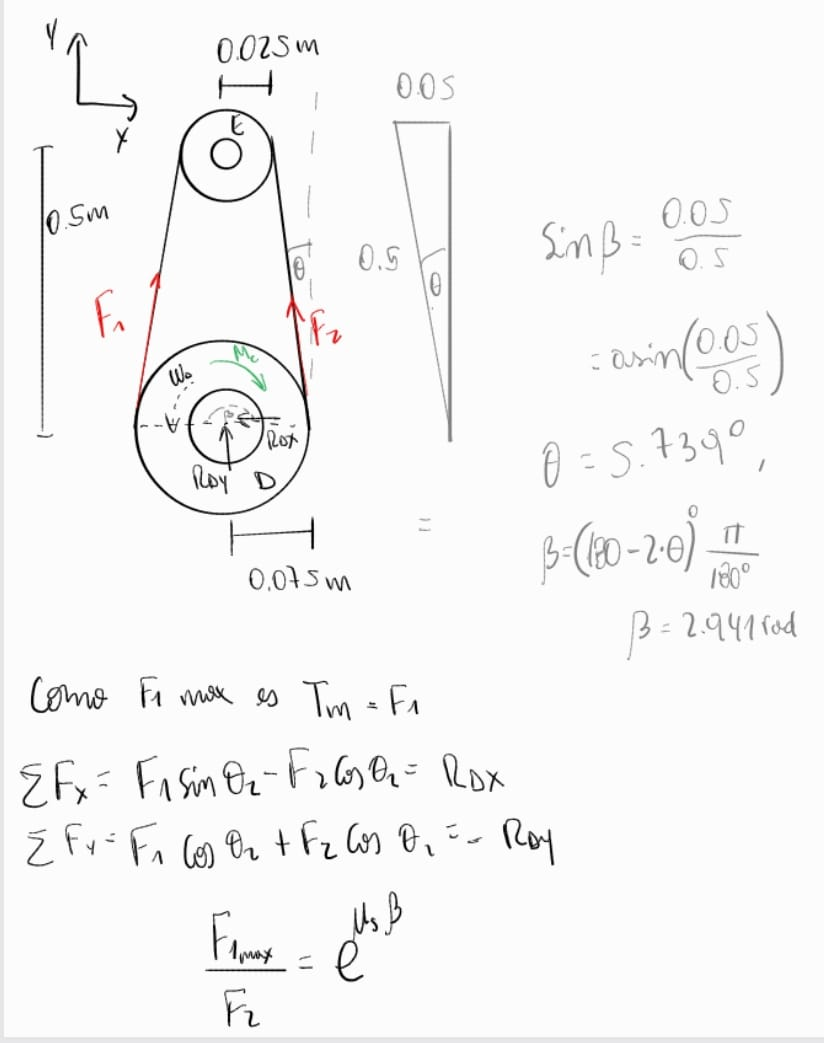
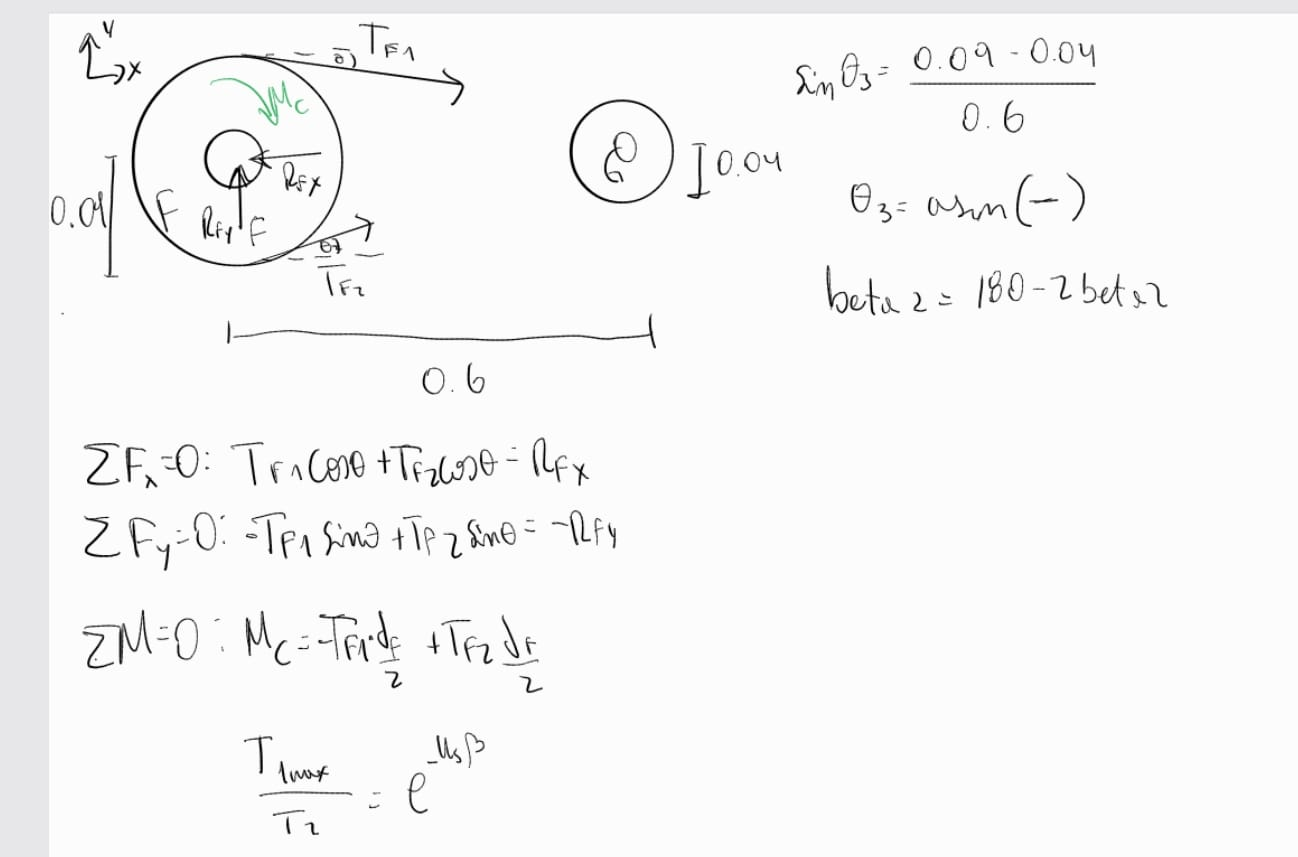

In [4]:
#DCL POLEA D
T_D2=M_D/((1-np.exp(u_s*beta_DE))*d_d/2) #[N]
T_D1=T_D2*np.exp(u_s*beta_DE) #[N]
R_DX= T_D1*np.sin(theta_DE)-T_D2*np.sin(theta_DE) #[n]
R_DY=-T_D1*np.cos(theta_DE)-T_D2*np.cos(theta_DE) #[N]
print(f'M_D:{M_D}N·m, R_Cx:{R_CX}N, R_Cy: {R_CY} N')
#DCL POLEA F
T_F2=M_F/((1-np.exp(u_s*beta_FG))*d_f/2) #[N]
T_F1=T_F2*np.exp(u_s*beta_FG) #[N]
R_FX= T_F1*np.cos(theta_FG)+T_F2*np.cos(theta_FG) #[n]
R_FY=+T_F1*np.sin(theta_FG)-T_F2*np.sin(theta_FG) #[N]
print(f'M_F:{M_F}N·m, R_Fx:{R_FX}N, R_Fy: {R_FY} N')
print(T_F2)

M_D:593.6479377327697N·m, R_Cx:7202.33929894147N, R_Cy: 19788.264591092324 N
M_F:593.6479377327697N·m, R_Fx:-15695.993407303073N, R_Fy: -549.6740164192312 N
-4577.345347073314


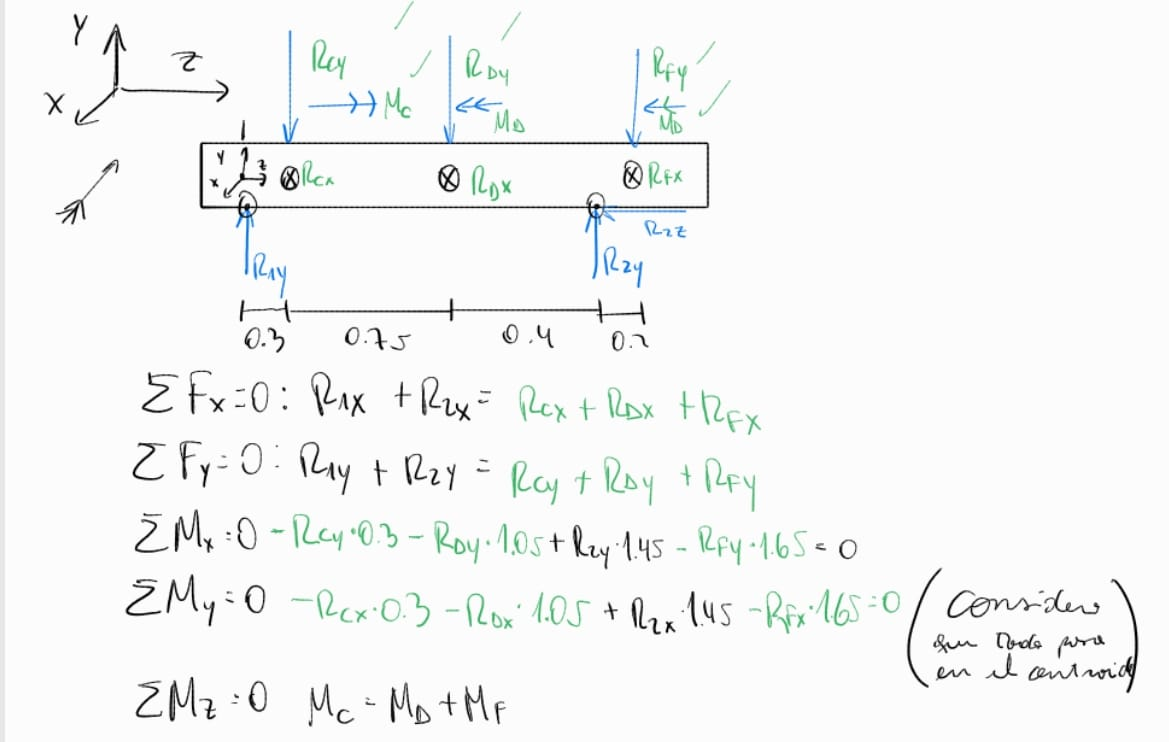

In [8]:
R_S2Y=(R_CY*0.3+R_DY*1.05+R_FY*1.65)/1.45 #Momento en X
R_S2X=(R_CX*0.3+R_DX*1.05+R_FX*1.65)/1.45 #Momento en Y
R_S1Y=R_CY+R_DY+R_FY-R_S2Y #Sumatoria en Y
R_S1X=R_CX+R_DX+R_FX-R_S2X #Sumatoria eje x

### Poleas B/C
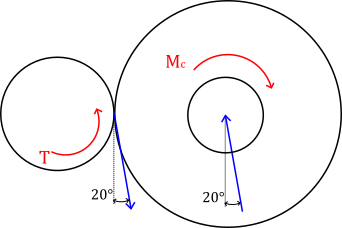

## Diagrama de corte

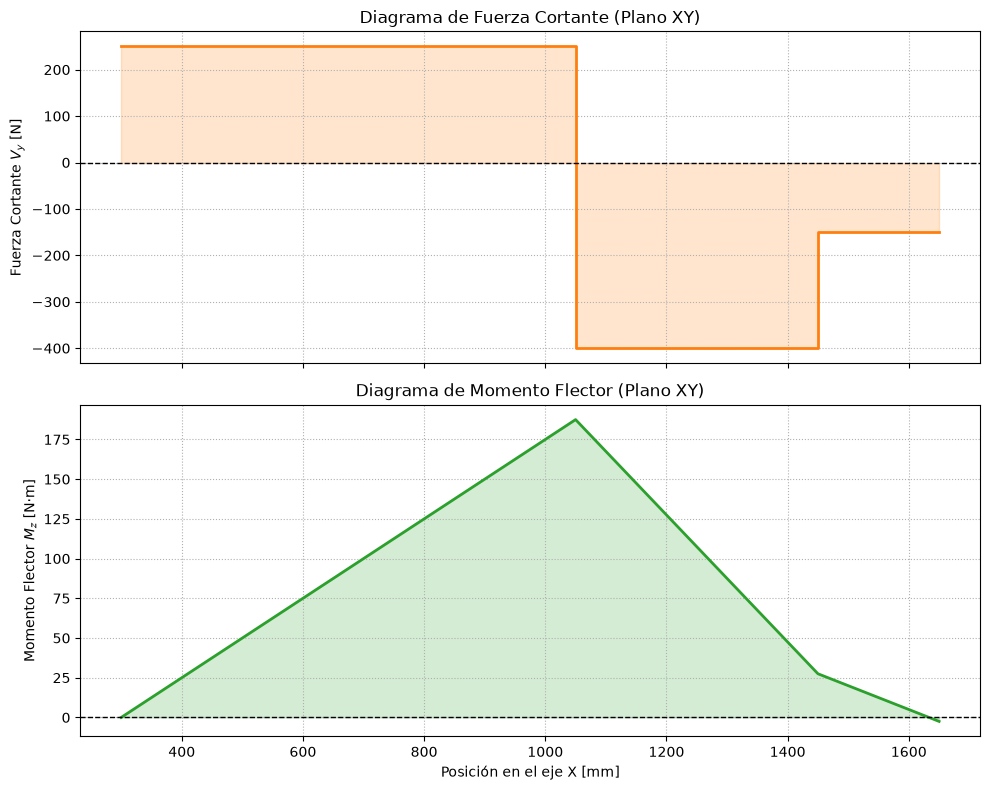

In [18]:
# 1. Definición de las posiciones en el eje X (en mm)
# x0 = 0      # Inicio del eje
x1 = 300    # Posición del Soporte 1 (Lado Motriz)
x2 = x1+750    # Posición del Engrane
x3 = x2+400    # Posición de la Polea D
x4 = x3+200   # Posición de la Polea F

# 2. Definición de tramos discretizados
n_pts = 100
# t1 = np.linspace(x0, x1, n_pts)
t2 = np.linspace(x1, x2, n_pts)
t3 = np.linspace(x2, x3, n_pts)
t4 = np.linspace(x3, x4, n_pts)

# Concatenación del eje X continuo
x_total = np.concatenate([t2, t3, t4])

# ==========================================
# 3. VALORES DE CORTE V_y PARA CADA TRAMO (N)
# Reemplazar V_t1, V_t2... con los valores de tus sumatorias
# ==========================================
# V_t1 = np.full_like(t1, 0.0)
V_t2 = np.full_like(t2, 250.0)   # Ejemplo: Cortante tras el Soporte 1
V_t3 = np.full_like(t3, -400.0)  # Ejemplo: Cortante tras el Engrane
V_t4 = np.full_like(t4, -150.0)  # Ejemplo: Cortante tras la Polea D

Vy_total = np.concatenate([ V_t2, V_t3, V_t4])

# ==========================================
# 4. ECUACIONES DE MOMENTO FLECTOR M_z (N*mm)
# M(x) = M_inicial_tramo + V * (x - x_inicio_tramo)
# ==========================================
# Tramo 1
# M_t1 = 0 + V_t1[0] * (t1 - x0)

# Tramo 2 (empieza en el valor final del Tramo 1)
M_inicio_2 = 0 #M_t1[-1]
M_t2 = M_inicio_2 + V_t2[0] * (t2 - x1)

# Tramo 3
M_inicio_3 = M_t2[-1]
M_t3 = M_inicio_3 + V_t3[0] * (t3 - x2)

# Tramo 4
M_inicio_4 = M_t3[-1]
M_t4 = M_inicio_4 + V_t4[0] * (t4 - x3)

# Tramo 5
M_inicio_5 = M_t4[-1]
M_t5 = M_inicio_5 + V_t5[0] * (t5 - x4)

Mz_total = np.concatenate([ M_t2, M_t3, M_t4])

# ==========================================
# 5. GRÁFICOS
# ==========================================
fig, (ax_v, ax_m) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Graficar Cortante V_y
ax_v.plot(x_total, Vy_total, color='tab:orange', linewidth=2, label='$V_y(x)$')
ax_v.fill_between(x_total, Vy_total, color='tab:orange', alpha=0.2)
ax_v.axhline(0, color='black', linestyle='--', linewidth=1)
ax_v.set_ylabel('Fuerza Cortante $V_y$ [N]')
ax_v.set_title('Diagrama de Fuerza Cortante (Plano XY)')
ax_v.grid(True, linestyle=':')

# Graficar Momento Flector M_z
ax_m.plot(x_total, Mz_total / 1000, color='tab:green', linewidth=2, label='$M_z(x)$') # Convertido a N*m
ax_m.fill_between(x_total, Mz_total / 1000, color='tab:green', alpha=0.2)
ax_m.axhline(0, color='black', linestyle='--', linewidth=1)
ax_m.set_xlabel('Posición en el eje X [mm]')
ax_m.set_ylabel('Momento Flector $M_z$ [N·m]')
ax_m.set_title('Diagrama de Momento Flector (Plano XY)')
ax_m.grid(True, linestyle=':')

plt.tight_layout()
plt.show()

ValueError: x and y must have same first dimension, but have shapes (50,) and (1,)

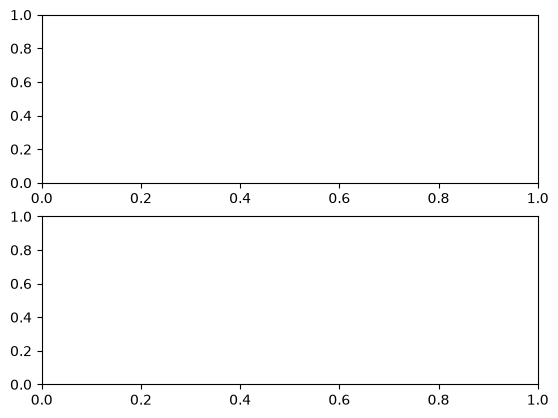

In [13]:
Z=np.linspace(0,1050)
V=R_S1Y-R_CY
fig, (ax1,ax2)= plt.subplots(2,1) 
ax1.plot(Z,V*len(Z))